# Diplomatura en IA - UP 
### Practico N°2 - Jun26
### Alumno: Gonzalez Marta Elizabeth 
### Notebook 04 - Entrenamiento -

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

pd.set_option('display.max_columns', None)

In [3]:
# Carga Dataset:

df = pd.read_csv("../data/processed/03_dataset_preprocesado.csv")


In [4]:
df.shape

(50000, 30)

In [5]:
df.columns.tolist()

['gender',
 'age',
 'height(cm)',
 'weight(kg)',
 'waist(cm)',
 'eyesight(left)',
 'eyesight(right)',
 'hearing(left)',
 'hearing(right)',
 'systolic',
 'relaxation',
 'fasting blood sugar',
 'Cholesterol',
 'triglyceride',
 'HDL',
 'LDL',
 'hemoglobin',
 'Urine protein',
 'serum creatinine',
 'AST',
 'ALT',
 'Gtp',
 'oral',
 'dental caries',
 'tartar',
 'smoking',
 'BMI',
 'WHR',
 'chol_hdl_ratio',
 'tri_hdl_ratio']

In [6]:
df.head()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking,BMI,WHR,chol_hdl_ratio,tri_hdl_ratio
0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0,24.973985,2.178763,2.945205,1.123288
1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0,23.437500,2.109375,4.571429,2.738095
2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1,20.761246,1.960784,4.400000,3.309091
3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,4.166667,2.500000,4.000000,13.416667,10.583333,1.875000,9.416667,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0,25.711662,2.222222,7.155556,5.644444
4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,5.000000,3.083333,3.333333,7.666667,3.083333,2.583333,4.458333,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0,24.973985,2.311828,2.967742,1.193548


In [7]:
# Separacion de variables:

X = df.drop("smoking", axis=1)

y = df["smoking"]

In [8]:
# Identificación de columnas

categoricas = [
    'gender',
    'oral',
    'tartar'
]

In [9]:
numericas = [
    col
    for col in X.columns
    if col not in categoricas
]

In [10]:
# División Train/Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [11]:
# Pipeline de preprocesamiento
#Numericas

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [12]:
# Pipeline de preprocesamiento
#Categoricas

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [13]:
#ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numericas),
    ('cat', categorical_transformer, categoricas)
])


### Modelo 1 - Logistic Regression

In [14]:
# Modelo 1 - Logistic Regression

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [15]:
pipeline_lr.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
pred_lr = pipeline_lr.predict(X_test)

In [17]:
f1_lr = f1_score(
    y_test,
    pred_lr
)

print("F1 Logistic Regression:", f1_lr)

F1 Logistic Regression: 0.6665796003656784


### Modelo 2 - Random Forest

In [18]:
# Modelo 2 - Random Forest

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=300
    ))
])

In [19]:
pipeline_rf.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
pred_rf = pipeline_rf.predict(X_test)

In [21]:
f1_rf = f1_score(
    y_test,
    pred_rf
)

print("F1 Random Forest:", f1_rf)

F1 Random Forest: 0.7353057199211045


### Modelo 3 - Gradient Boosting

In [22]:
# Modelo 3 - Gradient Boosting

pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        random_state=42
    ))
])

In [23]:
pipeline_gb.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
pred_gb = pipeline_gb.predict(X_test)

In [25]:
f1_gb = f1_score(
    y_test,
    pred_gb
)

print("F1 Gradient Boosting:", f1_gb)

F1 Gradient Boosting: 0.6958561376075059


### Comparación de modelos

In [26]:
# Comparación de modelos

resultados = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'F1 Score': [
        f1_lr,
        f1_rf,
        f1_gb
    ]
})

resultados.sort_values(
    by='F1 Score',
    ascending=False
)

,Modelo,F1 Score
1,Random Forest,0.735306
2,Gradient Boosting,0.695856
0,Logistic Regression,0.666580


In [27]:
# Selección automática del mejor modelo

modelos = {
    'Logistic Regression': pipeline_lr,
    'Random Forest': pipeline_rf,
    'Gradient Boosting': pipeline_gb
}

f1_scores = {
    'Logistic Regression': f1_lr,
    'Random Forest': f1_rf,
    'Gradient Boosting': f1_gb
}

In [28]:
mejor_nombre = max(
    f1_scores,
    key=f1_scores.get
)

print("Mejor modelo:", mejor_nombre)

Mejor modelo: Random Forest


In [29]:
best_model = modelos[mejor_nombre]

### Matriz de confusión mejor modelo

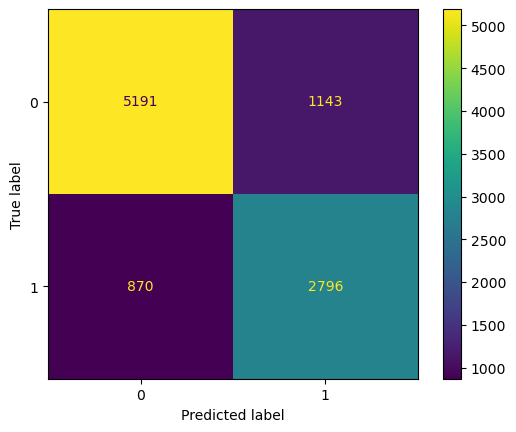

In [30]:
# Matriz de confusión

from sklearn.metrics import ConfusionMatrixDisplay

pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_best
)

In [32]:
# Classification Report

print(
    classification_report(
        y_test,
        pred_best
    )
)

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      6334
           1       0.71      0.76      0.74      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.79     10000
weighted avg       0.80      0.80      0.80     10000



In [33]:
# Validación Cruzada

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [34]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

In [35]:
print("F1 promedio:", cv_scores.mean())
print("Desvío:", cv_scores.std())

F1 promedio: 0.7367079909677775
Desvío: 0.0018730366852956828


In [36]:
# Guardado del mejor modelo

joblib.dump(
    best_model,
    "best_model.pkl"
)

['best_model.pkl']

In [37]:
print("Modelo guardado")

Modelo guardado


In [38]:
resultados.sort_values(
    by='F1 Score',
    ascending=False
)


,Modelo,F1 Score
1,Random Forest,0.735306
2,Gradient Boosting,0.695856
0,Logistic Regression,0.666580


In [39]:
print("Mejor modelo:", mejor_nombre)

Mejor modelo: Random Forest


In [40]:
print(
    classification_report(
        y_test,
        pred_best
    )
)

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      6334
           1       0.71      0.76      0.74      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.79     10000
weighted avg       0.80      0.80      0.80     10000



In [41]:
print("F1 promedio:", cv_scores.mean())
print("Desvío:", cv_scores.std())

F1 promedio: 0.7367079909677775
Desvío: 0.0018730366852956828
